# Laboratorio 3 – Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Semestre I – 2026
### InmoValor S.A. – Predicción de precios de viviendas

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)

**Objetivo:** Desarrollar modelos de regresión lineal para predecir el precio de venta (`SalePrice`) de viviendas en Ames, Iowa, a partir de 79 variables explicativas que describen aspectos como calidad, tamaño, ubicación y condición de las propiedades.

---

## 1. Importación de Librerías y Carga de Datos

In [2]:
%pip install -q pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, skew, kurtosis

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 85)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [5]:
# Carga de datos
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Dataset de entrenamiento: {train.shape[0]} filas x {train.shape[1]} columnas")
print(f"Dataset de prueba: {test.shape[0]} filas x {test.shape[1]} columnas")
print(f"\n Variable objetivo: SalePrice")
print(f"   - Presente en train: {'SalePrice' in train.columns}")
print(f"   - Presente en test: {'SalePrice' in test.columns}")

Dataset de entrenamiento: 1460 filas x 81 columnas
Dataset de prueba: 1459 filas x 80 columnas

 Variable objetivo: SalePrice
   - Presente en train: True
   - Presente en test: False


## 2. Descripción de las Variables

El dataset contiene **81 variables** (incluyendo `Id` y `SalePrice`). Las variables se pueden categorizar en los siguientes grupos temáticos:

| Categoría | Variables | Descripción |
|---|---|---|
| **Identificación** | `Id` | Identificador único de la propiedad |
| **Tipo de vivienda** | `MSSubClass`, `BldgType`, `HouseStyle` | Clasificación del tipo de construcción y estilo |
| **Zonificación y terreno** | `MSZoning`, `LotFrontage`, `LotArea`, `LotShape`, `LandContour`, `LotConfig`, `LandSlope` | Características del terreno y zonificación |
| **Acceso e infraestructura** | `Street`, `Alley`, `Utilities`, `PavedDrive` | Tipo de acceso y servicios disponibles |
| **Ubicación** | `Neighborhood`, `Condition1`, `Condition2` | Vecindario y proximidad a características |
| **Calidad general** | `OverallQual`, `OverallCond` | Calificación general de calidad y condición (1-10) |
| **Antigüedad** | `YearBuilt`, `YearRemodAdd` | Año de construcción y remodelación |
| **Techo** | `RoofStyle`, `RoofMatl` | Estilo y material del techo |
| **Exterior** | `Exterior1st`, `Exterior2nd`, `MasVnrType`, `MasVnrArea`, `ExterQual`, `ExterCond` | Materiales y calidad exterior |
| **Cimentación y sótano** | `Foundation`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinSF1`, `BsmtFinType2`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF` | Características del sótano |
| **Calefacción y aire** | `Heating`, `HeatingQC`, `CentralAir` | Sistema de calefacción y aire acondicionado |
| **Eléctrico** | `Electrical` | Sistema eléctrico |
| **Superficie habitable** | `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GrLivArea` | Pies cuadrados por nivel |
| **Baños** | `BsmtFullBath`, `BsmtHalfBath`, `FullBath`, `HalfBath` | Cantidad de baños |
| **Habitaciones** | `BedroomAbvGr`, `KitchenAbvGr`, `KitchenQual`, `TotRmsAbvGrd` | Habitaciones sobre nivel |
| **Funcionalidad** | `Functional` | Funcionalidad de la vivienda |
| **Chimenea** | `Fireplaces`, `FireplaceQu` | Número y calidad de chimeneas |
| **Garaje** | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`, `GarageArea`, `GarageQual`, `GarageCond` | Características del garaje |
| **Áreas exteriores** | `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` | Porches y áreas exteriores |
| **Piscina** | `PoolArea`, `PoolQC` | Área y calidad de piscina |
| **Otros** | `Fence`, `MiscFeature`, `MiscVal` | Cerca, características misceláneas |
| **Venta** | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` | Información de la venta |
| **Variable objetivo** | `SalePrice` | **Precio de venta de la vivienda (USD)** |

In [6]:
# Vista general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO")
print("=" * 80)
print(f"\nDimensiones: {train.shape}")
print(f"\nPrimeras 5 filas:")
train.head()

INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO

Dimensiones: (1460, 81)

Primeras 5 filas:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
# Clasificación de variables por tipo
numericas = train.select_dtypes(include=[np.number]).columns.tolist()
categoricas = train.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(numericas)}):")
print(f"   {numericas}\n")
print(f"Variables categóricas ({len(categoricas)}):")
print(f"   {categoricas}\n")

# Información detallada de tipos de datos
print("=" * 80)
print("TIPOS DE DATOS Y VALORES NO NULOS")
print("=" * 80)
train.info()

Variables numéricas (38):
   ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categóricas (43):
   ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fu

In [8]:
# Estadísticas descriptivas de variables numéricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
train[numericas].describe().T.round(2)

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


### 2.1 Análisis de Valores Faltantes

Un paso crucial en la exploración es identificar qué variables tienen datos faltantes, cuántos y por qué. En este dataset, muchos valores `NaN` en realidad significan "no aplica" (por ejemplo, `PoolQC = NaN` significa que no hay piscina).

Variables con valores faltantes: 19 de 81
Variables sin valores faltantes: 62



,Valores Faltantes,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


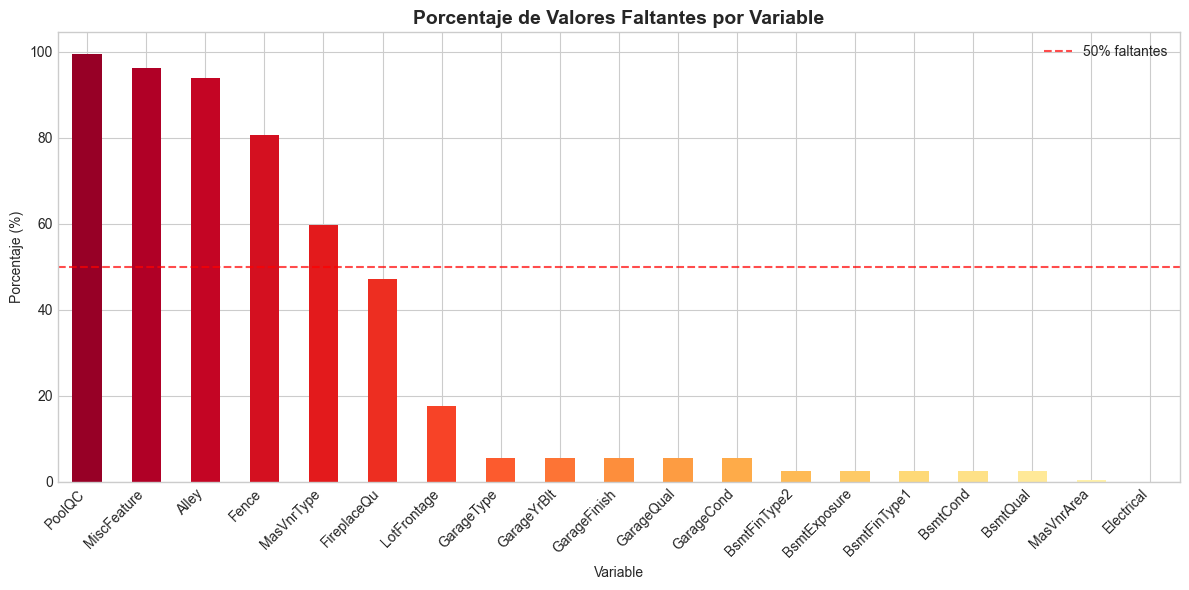

In [10]:
# Análisis de valores faltantes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje (%)': missing_pct
})

print(f"Variables con valores faltantes: {len(missing_df)} de {train.shape[1]}")
print(f"Variables sin valores faltantes: {train.shape[1] - len(missing_df)}\n")
display(missing_df)

# Visualización de valores faltantes
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct.plot(kind='bar', color=sns.color_palette("YlOrRd_r", len(missing_pct)), ax=ax)
ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Variable')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% faltantes')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hallazgos sobre valores faltantes:**

- **PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%), Fence (80.8%):** Estos altos porcentajes no son realmente "datos perdidos". Significan que la mayoría de casas no tienen piscina, característica miscelánea, acceso por callejón, o cerca. Son informativos y se codificarán como "None".
- **FireplaceQu (47.3%):** Casas sin chimenea. Se codificará como "None".
- **Variables de garaje (~5.5%):** `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt` — casas sin garaje.
- **Variables de sótano (~2.5%):** `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` — casas sin sótano.
- **LotFrontage (17.7%):** Este sí es un dato faltante real. Se imputará con la mediana del vecindario.
- **MasVnrType y MasVnrArea (~0.5%):** Pocas observaciones, se imputarán.
- **Electrical (0.07%):** Un solo valor faltante, se imputará con la moda.